# The State Space Lab

Companion notebook to the blog post
[**States Are Vectors**](https://jen1995.github.io/posts/states-are-vectors/).

Everything the post proved on paper can be poked at here: kets as columns of complex
numbers, the inner product with its conjugation, bras as functionals, Riesz's theorem
by construction, outer products as rank-one matrices, the resolution of identity —
and, at the end, the Hilbert-space concerns of infinite dimensions, with a square wave
escaping the space of continuous functions in front of your eyes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

INK, SEC, GREY, FAINT = "#0b0b0b", "#52514e", "#8a8983", "#c9c8c2"
BLUE, ORANGE, VIOLET, AQUA = "#2a78d6", "#eb6834", "#4a3aa7", "#1baf7a"
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "font.size": 10})
rng = np.random.default_rng(2026)

def show(name, v):
    print(f"{name:>8} = {np.round(v, 4)}")

## 1. Kets, and the inner product with its conjugation

The column model: a ket is a column of complex numbers. The inner product multiplies
the *conjugate* of the first vector by the second — and here is a practical trap.
NumPy's `np.dot` does **not** conjugate anything; `np.vdot` conjugates its **first**
argument, which is exactly the bra slot.

In [2]:
u = np.array([1, 0], dtype=complex)      # |u>
d = np.array([0, 1], dtype=complex)      # |d>

def braket(phi, psi):
    # <phi|psi> = sum(conj(phi_i) * psi_i)
    return np.vdot(phi, psi)

phi = np.array([1 + 2j, 3 - 1j])
psi = np.array([0.5j, 2 + 1j])

print("np.dot(phi, psi)  =", np.dot(phi, psi), "   <- no conjugation: NOT an inner product")
print("np.vdot(phi, psi) =", np.vdot(phi, psi), "   <- conjugates the first (bra) slot")
print("by hand           =", np.sum(np.conj(phi) * psi))

np.dot(phi, psi)  = (6+1.5j)    <- no conjugation: NOT an inner product
np.vdot(phi, psi) = (6+5.5j)    <- conjugates the first (bra) slot
by hand           = (6+5.5j)


Check the axioms numerically: Hermitian symmetry, linearity in the second slot,
*anti*-linearity in the first, and that $\langle\psi|\psi\rangle$ is real and positive.

In [3]:
a, b = 2 - 1j, 0.3 + 0.7j
zeta = rng.normal(size=2) + 1j * rng.normal(size=2)

print("Hermitian symmetry   <phi|psi> == conj(<psi|phi>):",
      np.isclose(braket(phi, psi), np.conj(braket(psi, phi))))
print("linear in 2nd slot   <phi|a psi + b zeta> == a<phi|psi> + b<phi|zeta>:",
      np.isclose(braket(phi, a*psi + b*zeta), a*braket(phi, psi) + b*braket(phi, zeta)))
print("ANTI-linear in 1st   <a phi|psi> == conj(a) <phi|psi>:",
      np.isclose(braket(a*phi, psi), np.conj(a)*braket(phi, psi)))
print("<psi|psi> =", braket(psi, psi), " -> real and positive")
print("scaling by i:  <i psi| i psi> =", braket(1j*psi, 1j*psi), " (still positive)")

Hermitian symmetry   <phi|psi> == conj(<psi|phi>): True
linear in 2nd slot   <phi|a psi + b zeta> == a<phi|psi> + b<phi|zeta>: True
ANTI-linear in 1st   <a phi|psi> == conj(a) <phi|psi>: True
<psi|psi> = (5.25+0j)  -> real and positive
scaling by i:  <i psi| i psi> = (5.25+0j)  (still positive)


## 2. Right and left — and why *in* and *out* need complex numbers

The post built $|r\rangle$ and $|l\rangle$ from two facts: fifty-fifty along $z$, and
mutually exclusive. Check both. Then the teaser: the $y$-axis states must be fifty-fifty
along $z$ **and** along $x$ **and** mutually exclusive. Scan every *real* unit vector
$(\cos t, \sin t)$ and watch: no real vector is fifty-fifty with respect to both bases
except $|r\rangle$ and $|l\rangle$ themselves — which are of course not orthogonal to
themselves. The $y$ states have to leave the real plane.

In [4]:
r = (u + d) / np.sqrt(2)
l = (u - d) / np.sqrt(2)

print("|<u|r>|^2 =", abs(braket(u, r))**2, "  |<d|r>|^2 =", abs(braket(d, r))**2)
print("<r|l> =", np.round(braket(r, l), 12), "  <r|r> =", braket(r, r).real)

# the real-vector scan
t = np.linspace(0, 2*np.pi, 3601)
real_vectors = np.stack([np.cos(t), np.sin(t)], axis=1)
p_u = np.abs(real_vectors @ np.conj(u))**2       # |<u|v>|^2 for every candidate
p_r = np.abs(real_vectors @ np.conj(r))**2       # |<r|v>|^2
fifty_fifty_both = np.isclose(p_u, 0.5, atol=1e-3) & np.isclose(p_r, 0.5, atol=1e-3)
print("real unit vectors that are fifty-fifty in BOTH the z and the x basis:",
      fifty_fifty_both.sum(), "out of", len(t))

# the complex ones that do the job
i_ket = (u + 1j*d) / np.sqrt(2)
o_ket = (u - 1j*d) / np.sqrt(2)
for name, v in [("|i>", i_ket), ("|o>", o_ket)]:
    print(f"{name}: |<u|.>|^2={abs(braket(u,v))**2:.2f}  |<r|.>|^2={abs(braket(r,v))**2:.2f}"
          f"  |<l|.>|^2={abs(braket(l,v))**2:.2f}")
print("<i|o> =", np.round(braket(i_ket, o_ket), 12))

|<u|r>|^2 = 0.4999999999999999   |<d|r>|^2 = 0.4999999999999999
<r|l> = (-0+0j)   <r|r> = 0.9999999999999998
real unit vectors that are fifty-fifty in BOTH the z and the x basis: 0 out of 3601
|i>: |<u|.>|^2=0.50  |<r|.>|^2=0.50  |<l|.>|^2=0.50
|o>: |<u|.>|^2=0.50  |<r|.>|^2=0.50  |<l|.>|^2=0.50
<i|o> = 0j


## 3. Bras as functionals, and Riesz by construction

A linear functional on $\mathbb C^2$ is a row: feed it the basis columns and the two
numbers it returns *are* the row. Riesz's theorem says the functional is the inner
product with one specific ket — and the post's proof built it: the ket whose
coordinates are the **conjugates** of $L(|E_i\rangle)$. Take a random functional and
check.

In [5]:
row = rng.normal(size=2) + 1j * rng.normal(size=2)      # a random linear functional L
L = lambda ket: row @ ket                                # row times column

# the Riesz vector: coordinates conj(L(E_i)) in the orthonormal basis {u, d}
riesz = np.conj(L(u)) * u + np.conj(L(d)) * d

for trial in range(3):
    ket = rng.normal(size=2) + 1j * rng.normal(size=2)
    print(f"L(ket) = {L(ket):.4f}    <riesz|ket> = {braket(riesz, ket):.4f}")

print("\nthe bra of a column is its conjugate transpose (in an orthonormal basis):")
print("  row              :", np.round(row, 4))
print("  conj(riesz)      :", np.round(np.conj(riesz), 4))

L(ket) = -0.0366+0.3242j    <riesz|ket> = -0.0366+0.3242j
L(ket) = 0.2208+0.2761j    <riesz|ket> = 0.2208+0.2761j
L(ket) = -0.0409+0.6106j    <riesz|ket> = -0.0409+0.6106j

the bra of a column is its conjugate transpose (in an orthonormal basis):
  row              : [ 0.6383-0.3119j -0.292 +0.3038j]
  conj(riesz)      : [ 0.6383-0.3119j -0.292 +0.3038j]


## 4. Outer products: rank-one matrices, and the identity resolved

A column times a row is a matrix. `np.outer(a, np.conj(b))` builds $|a\rangle\langle b|$.
Each $|E_i\rangle\langle E_i|$ is a projector of rank one; their sum over an orthonormal
basis is the identity — in the $z$ basis, in the $x$ basis, in any orthonormal basis.

In [6]:
def ketbra(a, b):
    return np.outer(a, np.conj(b))       # |a><b|

for name, E in [("u", u), ("d", d), ("r", r), ("l", l)]:
    P = ketbra(E, E)
    print(f"|{name}><{name}| =\n{np.round(P, 3)}   rank = {np.linalg.matrix_rank(P)}")

print("sum over the z basis:\n", np.round(ketbra(u, u) + ketbra(d, d), 12))
print("sum over the x basis:\n", np.round(ketbra(r, r) + ketbra(l, l), 12))

|u><u| =
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]   rank = 1
|d><d| =
[[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]   rank = 1
|r><r| =
[[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]   rank = 1
|l><l| =
[[ 0.5+0.j -0.5-0.j]
 [-0.5+0.j  0.5+0.j]]   rank = 1
sum over the z basis:
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
sum over the x basis:
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


Insert the identity between a bra and a ket, in a basis of your choosing — the number
cannot change, but the computation now runs along that basis:
$\langle\phi|\psi\rangle = \sum_i \langle\phi|E_i\rangle\langle E_i|\psi\rangle$.

In [7]:
phi = rng.normal(size=2) + 1j * rng.normal(size=2)
psi = rng.normal(size=2) + 1j * rng.normal(size=2)

direct = braket(phi, psi)
via_z  = sum(braket(phi, E) * braket(E, psi) for E in (u, d))
via_x  = sum(braket(phi, E) * braket(E, psi) for E in (r, l))
print("direct :", np.round(direct, 6))
print("via z  :", np.round(via_z, 6))
print("via x  :", np.round(via_x, 6))

# a projector really projects: |E><E| psi = <E|psi> |E>
show("P_r psi", ketbra(r, r) @ psi)
show("<r|psi> r", braket(r, psi) * r)

direct : (0.856882+1.646119j)
via z  : (0.856882+1.646119j)
via x  : (0.856882+1.646119j)
 P_r psi = [1.2332+0.3175j 1.2332+0.3175j]
<r|psi> r = [1.2332+0.3175j 1.2332+0.3175j]


## 5. Coordinates are inner products — and the Born rule in every basis

Take a random unit state. Its coordinates in the $z$ basis are $\langle u|\psi\rangle,
\langle d|\psi\rangle$; in the $x$ basis, $\langle r|\psi\rangle, \langle l|\psi\rangle$.
The squared magnitudes are the Born probabilities — and they sum to one in *every*
orthonormal basis, because each sum is just $\langle\psi|\psi\rangle$ with an identity
inserted. (Why the *square*, and not some other function of the amplitude, is the
next-but-one post's whole story.)

In [8]:
psi = rng.normal(size=2) + 1j * rng.normal(size=2)
psi = psi / np.sqrt(braket(psi, psi).real)          # normalize

for label, basis in [("z", (u, d)), ("x", (r, l)), ("y", (i_ket, o_ket))]:
    amps = [braket(E, psi) for E in basis]
    probs = [abs(c)**2 for c in amps]
    print(f"{label} basis:  amplitudes {np.round(amps, 3)}   probabilities {np.round(probs, 3)}"
          f"   sum = {sum(probs):.6f}")

z basis:  amplitudes [-0.565-0.537j  0.08 +0.621j]   probabilities [0.608 0.392]   sum = 1.000000
x basis:  amplitudes [-0.343+0.059j -0.456-0.819j]   probabilities [0.121 0.879]   sum = 1.000000
y basis:  amplitudes [ 0.039-0.437j -0.839-0.323j]   probabilities [0.192 0.808]   sum = 1.000000


And a measurement, simulated from the state vector alone: sample the outcome with the
Born probabilities, then collapse onto the basis ket that came up. This is the same
`Apparatus` as in the [Spin Lab](https://github.com/jen1995/jen1995.github.io/blob/main/notebooks/spin_lab.ipynb)
notebook, now with its answer key written in the language of this post.

In [9]:
def measure(psi, basis, outcomes=(+1, -1)):
    probs = np.array([abs(braket(E, psi))**2 for E in basis])
    k = rng.choice(len(basis), p=probs / probs.sum())
    return outcomes[k], basis[k]              # the outcome, and the collapsed state

state = r.copy()                               # prepared right
tape = []
for _ in range(20):
    outcome, state = measure(state, (u, d))    # ask the z question
    tape.append(outcome)
print("right electron, measured along z: ", " ".join(f"{o:+d}" for o in tape))

counts = [measure(r, (u, d))[0] for _ in range(5000)]
print("frequency of +1 over 5000 fresh right electrons:", np.mean(np.array(counts) > 0))

right electron, measured along z:  +1 +1 +1 +1 +1 +1 +1 +1 +1 +1 +1 +1 +1 +1 +1 +1 +1 +1 +1 +1
frequency of +1 over 5000 fresh right electrons: 0.4936


## 6. Completeness: a sequence that leaves the space

The post's example: partial Fourier sums of a square wave. Every partial sum is a
continuous function; the sums come closer and closer to each other in the $L^2$ norm
(a Cauchy sequence) — and yet their limit is a step, which is not continuous. Move
`N_SHOW` and watch the last column: the overshoot next to the jump settles at about
0.18 (the Gibbs phenomenon) and never shrinks — convergence happens in the norm, not
uniformly, and the limit has left the space of continuous functions.

 N    ||s_N - s_2N+1||_L2   ||s_N - step||_L2   overshoot max(s_N) - 1
  1             0.3001             0.4349               0.2732
  3             0.2213             0.3148               0.2004
  5             0.1823             0.2583               0.1884
  9             0.1419             0.2004               0.1823
 17             0.1060             0.1492               0.1800
 33             0.0772             0.1080               0.1793
 65             0.0554             0.0768               0.1790
129             0.0395             0.0538               0.1784


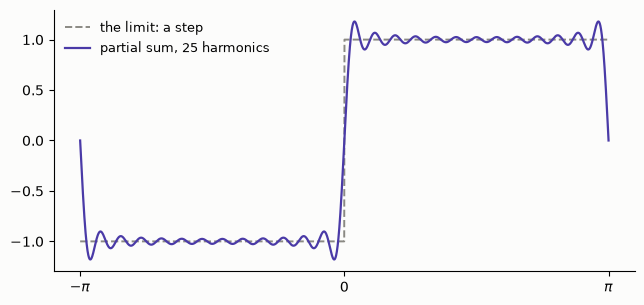

In [10]:
x = np.linspace(-np.pi, np.pi, 4001)
square = np.sign(np.sin(x))
def partial(N):
    return sum(4/(np.pi*k) * np.sin(k*x) for k in range(1, N+1, 2))

def l2_norm(f):
    return np.sqrt(np.trapezoid(np.abs(f)**2, x) / (2*np.pi))

Ns = [1, 3, 5, 9, 17, 33, 65, 129]
print(" N    ||s_N - s_2N+1||_L2   ||s_N - step||_L2   overshoot max(s_N) - 1")
for N in Ns:
    print(f"{N:>3}   {l2_norm(partial(N) - partial(2*N + 1)):>16.4f}   "
          f"{l2_norm(partial(N) - square):>16.4f}   {np.max(partial(N)) - 1:>18.4f}")

N_SHOW = 25
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(x, square, color=GREY, ls="--", lw=1.4, label="the limit: a step")
ax.plot(x, partial(N_SHOW), color=VIOLET, lw=1.6, label=f"partial sum, {N_SHOW} harmonics")
ax.set_xticks([-np.pi, 0, np.pi]); ax.set_xticklabels([r"$-\pi$", "0", r"$\pi$"])
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=9)
plt.show()

The $L^2$ distances to the step go to zero — the sequence converges in the Hilbert space
$L^2$, where the step is a perfectly good element. The overshoot does not go to zero:
that is the Gibbs phenomenon, and it is the fingerprint of a limit that no continuous
function can be.

## 7. $L^2$ as a Hilbert space: harmonics are an orthonormal basis

Numerically integrate $\langle e_m | e_n \rangle = \frac{1}{2\pi}\int e^{-imx} e^{inx}\,dx$
and watch the Kronecker delta appear. Then take a function, compute its coordinates
as inner products — the Fourier coefficients — and rebuild it from the basis.

Gram matrix of the harmonics e_{-3..3} (real part, rounded):
[[ 1.  0. -0.  0. -0.  0. -0.]
 [ 0.  1.  0. -0.  0. -0.  0.]
 [-0.  0.  1.  0. -0.  0. -0.]
 [ 0. -0.  0.  1.  0. -0.  0.]
 [-0.  0. -0.  0.  1.  0. -0.]
 [ 0. -0.  0. -0.  0.  1.  0.]
 [-0.  0. -0.  0. -0.  0.  1.]]


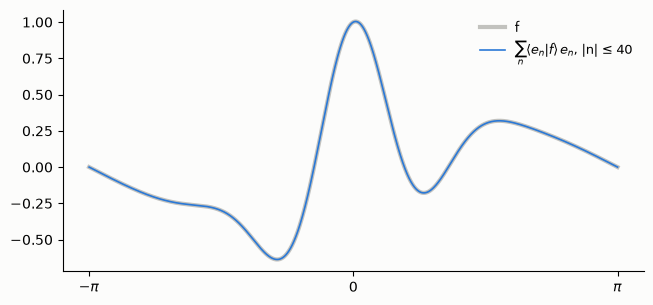

L2 distance between f and its 81-term reconstruction: 3.2712258634975906e-07


In [11]:
def e(n):
    return np.exp(1j * n * x)

def inner(f, g):                              # <f|g> in L^2 on [-pi, pi], normalized
    return np.trapezoid(np.conj(f) * g, x) / (2*np.pi)

G = np.array([[inner(e(m), e(n)) for n in range(-3, 4)] for m in range(-3, 4)])
print("Gram matrix of the harmonics e_{-3..3} (real part, rounded):")
print(np.round(G.real, 3))

f = np.exp(-x**2) * np.cos(3*x) + 0.3 * np.sin(x)   # a smooth periodic function
coeffs = {n: inner(e(n), f) for n in range(-40, 41)}
rebuilt = sum(c * e(n) for n, c in coeffs.items())

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(x, f, color=GREY, lw=3, alpha=0.5, label="f")
ax.plot(x, rebuilt.real, color=BLUE, lw=1.2, label=r"$\sum_n \langle e_n|f\rangle\, e_n$, |n| ≤ 40")
ax.set_xticks([-np.pi, 0, np.pi]); ax.set_xticklabels([r"$-\pi$", "0", r"$\pi$"])
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=9)
plt.show()
print("L2 distance between f and its 81-term reconstruction:", l2_norm(f - rebuilt))

## Things to try

- In section 1, replace `np.vdot` by `np.dot` inside `braket` and rerun the axiom checks:
  which ones fail, and why is $\langle\psi|\psi\rangle$ no longer positive?
- In section 4, build the resolution of identity in the $y$ basis $\{|i\rangle, |o\rangle\}$
  and insert it into a bracket.
- In section 6, try the sawtooth $x/\pi$ instead of the square wave — another continuous
  sequence with a discontinuous limit (at the endpoints).
- In section 7, drop the $1/2\pi$ in `inner` and see the Gram matrix stop being the identity:
  orthogonal, but no longer ortho*normal*.

Back to the road: [States Are Vectors](https://jen1995.github.io/posts/states-are-vectors/).